In [1]:
# Code to test everything is working fine. 
import os 
import sys
sys.path.append("../../")


import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib as mpl
from torch.utils.data import DataLoader, Dataset

from vi_rnn.vae import VAE
from vi_rnn.train import train_VAE 
from vi_rnn.utils import *
from vi_rnn.evaluation import * 
from vi_rnn.saving import save_model, load_model
from vi_rnn.datasets import DTTDataset

from py_rnn.model import RNN, predict
from py_rnn.train import train_rnn
from py_rnn.train import save_rnn, load_rnn
from py_rnn.default_params import get_default_params

import pandas as pd 

from sklearn.model_selection import train_test_split

from data.utils import * 

from evaluation.calc_stats import calc_isi_stats
from scipy.signal import convolve, gaussian
%matplotlib inline

### Load spikes and neuromodulation signal

In [2]:
data_dir = '../../data/recordings/nk341_mPFC/' 
out_dir = "../../models/dtt/" 

sampling_rate = 30_000 # khz
t_start_baseline, t_end_baseline = 10, 600
t_start_post_trial, t_end_post_trial = 6_689, 7_869
bin_size = 0.02
bs = 256 # batch size 

smooth = True

In [3]:
def load_data():
    spikes = []

    spikes_dir = os.path.join(data_dir, 'spikes')

    t_start, t_end = 10, 0
    for f in os.listdir(spikes_dir):
        spikes_df = pd.read_csv(f'{spikes_dir}/{f}', header=None)
        spikes.append(spikes_df.to_numpy().flatten() / sampling_rate)
        t_end = max(t_end, int(np.ceil(spikes[-1].max())))

    print(f't_end = {t_end}')
    spike_counts = np.zeros((len(spikes), int((t_end - t_start) / bin_size)))
    for i in range(len(spikes)):
        spike_counts[i], _ = bin_spike_train(spikes[i], t_start, t_end, bin_size)

    # load neuromodulation signal 
    neuromod_dir = os.path.join(data_dir, 'neuromodulators')
    lc_neuromod = pd.read_csv(f'{neuromod_dir}/norepinephrine.csv', header=None).to_numpy().flatten()
    # z-score 
    neuromod_activity = (lc_neuromod - lc_neuromod.mean()) / lc_neuromod.std()
    if smooth:
        kernel_size = 100
        sigma = 30
        gaussian_kernel = gaussian(kernel_size, sigma) 
        gaussian_kernel /= gaussian_kernel.sum()
        neuromod_activity = convolve(neuromod_activity, gaussian_kernel, mode='full')
    # load trials info 
    trials_dir = os.path.join(data_dir, 'trials') 
    trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

    return spikes, spike_counts, neuromod_activity, trials_df 

In [4]:
spikes, spike_counts, neuromod_activity, trials_df = load_data()

t_end = 7889


C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26732\1618301055.py:25: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  gaussian_kernel = gaussian(kernel_size, sigma)


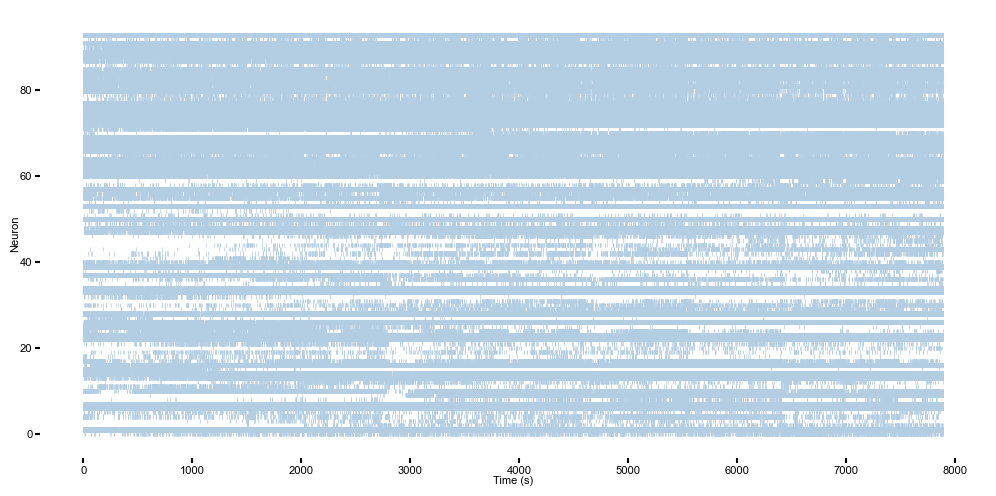

In [5]:
cmap = mpl.colormaps["Pastel1"]
color = cmap(1)
plt.figure(figsize=(10, 5))
plt.eventplot(spikes, linewidths=0.5, colors=color) 
plt.xlabel("Time (s)")
plt.ylabel("Neuron")

# hide the right and top spines
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.tight_layout()

In [6]:
trials_df.head()

,id,t,trialtype,cs,us,vacuum,opto_on,opto_off,ustype,us_stop,cstype,first_lick
0,1,630.818133,ODOR-ON_1,NaN,631.343300,NaN,NaN,NaN,Odor,641.322667,NaN,631.344
1,2,671.726933,ODOR-ON_1,NaN,672.246433,NaN,NaN,NaN,Odor,682.248533,NaN,NaN
2,3,712.516267,ODOR-ON_1,NaN,713.060933,NaN,NaN,NaN,Odor,723.054933,NaN,NaN
3,4,753.399467,PAUSE_120,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,875.153067,TONE_1_LAG_500_REW_1_LAG_2000_VACUUM_1,875.656533,877.389600,879.399833,NaN,NaN,REW_1,NaN,NaN,880.039


### Split baseline period into training and testing samples and filter out neurons with little activity

In [7]:
trials_dir = os.path.join(data_dir, 'trials') 
trials_df = pd.read_csv(os.path.join(trials_dir, 'trials.csv'))

In [8]:
def get_block(spike_counts, neuromod_activity, t_start, t_end):
    block_dur = int((t_end - t_start) / bin_size)
    block_start_idx = int(t_start / bin_size) 
    spike_counts_block = spike_counts[:, block_start_idx:block_start_idx + block_dur]
    s_block = neuromod_activity[block_start_idx:block_start_idx + block_dur]
    return spike_counts_block, s_block 

#### Get first 10 minutes block

In [9]:
spike_counts_baseline, s_baseline = get_block(spike_counts, neuromod_activity, t_start_baseline, t_end_baseline)
dur_baseline = s_baseline.shape[0]
print(dur_baseline)
#divide into train and test samples 
train_size_baseline = int(dur_baseline * 0.75)
test_size_baseline = dur_baseline - train_size_baseline
print(f'Train sample size: {train_size_baseline}')
print(f'Test sample size: {test_size_baseline}')

train_samples = spike_counts_baseline[:, :train_size_baseline]
test_samples = spike_counts_baseline[:, train_size_baseline:]
s_train = s_baseline[:train_size_baseline]
s_test = s_baseline[train_size_baseline:]

29500
Train sample size: 22125
Test sample size: 7375


#### Get last 20 minutes block

In [10]:
spike_counts_pt_baseline, s_pt_baseline = get_block(spike_counts, neuromod_activity, t_start_post_trial, t_end_post_trial)
dur_pt_baseline = s_pt_baseline.shape[0]
print(dur_pt_baseline)
#divide into train and test samples 
train_size_pt_baseline = int(dur_pt_baseline * 0.75)
test_size_pt_baseline = dur_pt_baseline - train_size_pt_baseline
print(f'Train sample size: {train_size_pt_baseline}')
print(f'Test sample size: {dur_pt_baseline - train_size_pt_baseline}')

train_samples_pt = spike_counts_pt_baseline[:, :train_size_pt_baseline]
test_samples_pt = spike_counts_pt_baseline[:, train_size_pt_baseline:]
s_train_pt = s_pt_baseline[:train_size_pt_baseline]
s_test_pt = s_pt_baseline[train_size_pt_baseline:]

59000
Train sample size: 44250
Test sample size: 14750


In [11]:
seq_periods = [[0, train_size_baseline], [train_size_baseline, train_size_baseline + train_size_pt_baseline]]
seq_periods_eval = [[0, test_size_baseline], [test_size_baseline, test_size_baseline + test_size_pt_baseline]]

train_samples = np.hstack([train_samples, train_samples_pt])
test_samples = np.hstack([test_samples, test_samples_pt])
s_train = np.hstack([s_train, s_train_pt])
s_test = np.hstack([s_test, s_test_pt])

In [12]:
s_test.shape

(22125,)

#### Get airpuff blocks

In [13]:
trials_df['t'] *= 50
airpuff_trial_times = trials_df[trials_df['trialtype'] == 'TONE_3_LAG_500_AIRPUFF_1']['t'].astype('int').to_list()
print(airpuff_trial_times)

[145744, 148534, 151322, 191356, 194143, 196935]


In [14]:
# for each trial time, get a 20s block of neural and neuromodulatory activity
for t in airpuff_trial_times:
    t_s = t / 50.0 #convert back to seconds 
    t_start, t_end = t_s - 10, t_s + 10
    spike_counts_airpuff, s_airpuff = get_block(spike_counts, neuromod_activity, t_start, t_end) 
    seq_len = spike_counts_airpuff.shape[1]
    print(t_start, t_end, seq_len)
    # append to test samples
    test_samples = np.hstack([test_samples, spike_counts_airpuff])
    s_test = np.hstack([s_test, s_airpuff])
    prev_seq_idx = seq_periods_eval[-1][1]
    seq_periods_eval.append([prev_seq_idx, prev_seq_idx + seq_len])

2904.88 2924.88 1000
2960.68 2980.68 1000
3016.44 3036.44 1000
3817.12 3837.12 1000
3872.86 3892.86 1000
3928.7 3948.7 1000


In [15]:
s_test.shape, test_samples.shape

((28125,), (94, 28125))

In [16]:
task_params = {
            "dur": 100,
            "n_trials": 12000,
            "name": "",
            "dataset_name": data_dir,
        }
task = DTTDataset(task_params, 
    train_samples.T, 
    s_train=s_train, 
    s_test=s_test,
    seq_periods=seq_periods,
    seq_periods_eval=seq_periods_eval,
    data_eval=test_samples.T)

In [17]:
task.s_test.shape

torch.Size([1, 28125])

### Load models

In [19]:
models = {}
neuromodulation = ['None', 'additive']
ranks = [3] 
N_counts = [spike_counts_baseline.shape[0], 256, 512]
filters = ['filtered', 'unfiltered']

for neuromod in neuromodulation:
    for rank in ranks:
        for N in N_counts:
            for filter in filters:
                if filter == 'filtered' and neuromod != 'None':
                    vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_{neuromod}_rank_{rank}_{N}_filtered')
                else:
                    vae, params, task_params, training_params = load_model(f'../../models/dtt/dtt_{neuromod}_rank_{rank}_{N}')            
                models[(neuromod, rank, N, filter)] = vae

dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using ReLU activation
using uniform init
weight scaler 1
using acausal constant padding
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using ReLU activation
using uniform init
weight scaler 1
using acausal constant padding
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using ReLU activation
using uniform init
weight scaler 1
using acausal constant padding
dict_keys(['dim_x', 'dim_z', 'dim_N', 'dim_s', 'enc_architecture', 'enc_params', 'rnn_params', 'causal', 'rnn_architecture'])
Neuromodulation type: None
using ReLU activation
using uniform init
weight scaler 1
using acausal constant padding
dict_keys(['dim_x', 'dim_z', 'dim_N'

c:\Users\kaleab.belay\Documents\Project\mnm\train_scripts\recordings\../..\vi_rnn\saving.py:159: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return lambda b: torch.load(io

### 2. Baseline evaluation

#### 2.1. Generate spikes for baseline testing period

In [26]:
spike_preds = {}

for model in models.keys():
    neuromod, rank, N, filtered = model 
    print(neuromod, rank, N)
    vae = models[model]
    for i, block in enumerate(task.seq_periods_eval):
        block_start = block[0]
        block_end = block[1] 
        T = block_end - block_start 
        z_hat, _, _, _ = vae.encoder(task.data_eval[block_start:block_end, :].T.unsqueeze(0))
        z0 = z_hat[:, :, 0].squeeze() 
        sim_s, s_test_block = False, None 
        if neuromod != 'None':
            s_test_block = task.s_test[:, block_start:block_end].unsqueeze(0) 
        if neuromod == 'additive': 
            Z, S = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False, sim_s=True)
            lmd = vae.rnn.get_observation(Z, s=S, noise_scale=0)[0, :, :, 0]
        else: 
            Z = vae.rnn.get_latent_time_series(time_steps=T, cut_off=0, z0=z0, s=s_test_block, noise_scale=1, sim_v=False)
            lmd = vae.rnn.get_observation(Z, noise_scale=0)[0, :, :, 0]

   
        spikes_pred_1 = torch.poisson(lmd).T.detach()
        spikes_pred_2 = torch.poisson(lmd).T.detach()
        spike_preds[(neuromod, rank, N, filtered, i)] = spikes_pred_1
        spike_preds[(neuromod, rank, N, filtered, i)] = spikes_pred_2
    

None 3 94
no input
no input
no input
no input
no input
no input
no input
no input
None 3 94
no input
no input
no input
no input
no input
no input
no input
no input
None 3 256
no input
no input
no input
no input
no input
no input
no input
no input
None 3 256
no input
no input
no input
no input
no input
no input
no input
no input
None 3 512
no input
no input
no input
no input
no input
no input
no input
no input
None 3 512
no input
no input
no input
no input
no input
no input
no input
no input
additive 3 94
no input
no input
no input
no input
no input
no input
no input
no input
additive 3 94
no input
no input
no input
no input
no input
no input
no input
no input
additive 3 256
no input
no input
no input
no input
no input
no input
no input
no input
additive 3 256
no input
no input
no input
no input
no input
no input
no input
no input
additive 3 512
no input
no input
no input
no input
no input
no input
no input
no input
additive 3 512
no input
no input
no input
no input
no input
no input
no

In [32]:
spike_preds[model_1].shape

torch.Size([1000, 94])

C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26732\1248291049.py:12: DeprecationWarning: Importing gaussian from 'scipy.signal' is deprecated and will raise an error in SciPy 1.13.0. Please use 'scipy.signal.windows.gaussian' or the convenience function 'scipy.signal.get_window' instead.
  gaussian_kernel = gaussian(kernel_size, sigma)
C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26732\1248291049.py:29: RuntimeWarning: invalid value encountered in divide
  conv_gen_1 = (conv_gen_1 - conv_gen_1[:partial_idx].mean()) / conv_gen_1[:partial_idx].std()
C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26732\1248291049.py:30: RuntimeWarning: invalid value encountered in divide
  conv_gen_2 = (conv_gen_2 - conv_gen_2[:partial_idx].mean()) / conv_gen_2[:partial_idx].std()
C:\Users\kaleab.belay\AppData\Local\Temp\ipykernel_26732\1248291049.py:32: RuntimeWarning: invalid value encountered in divide
  conv_test = (conv_test - conv_test[:partial_idx].mean()) / conv_test[:partial_idx].

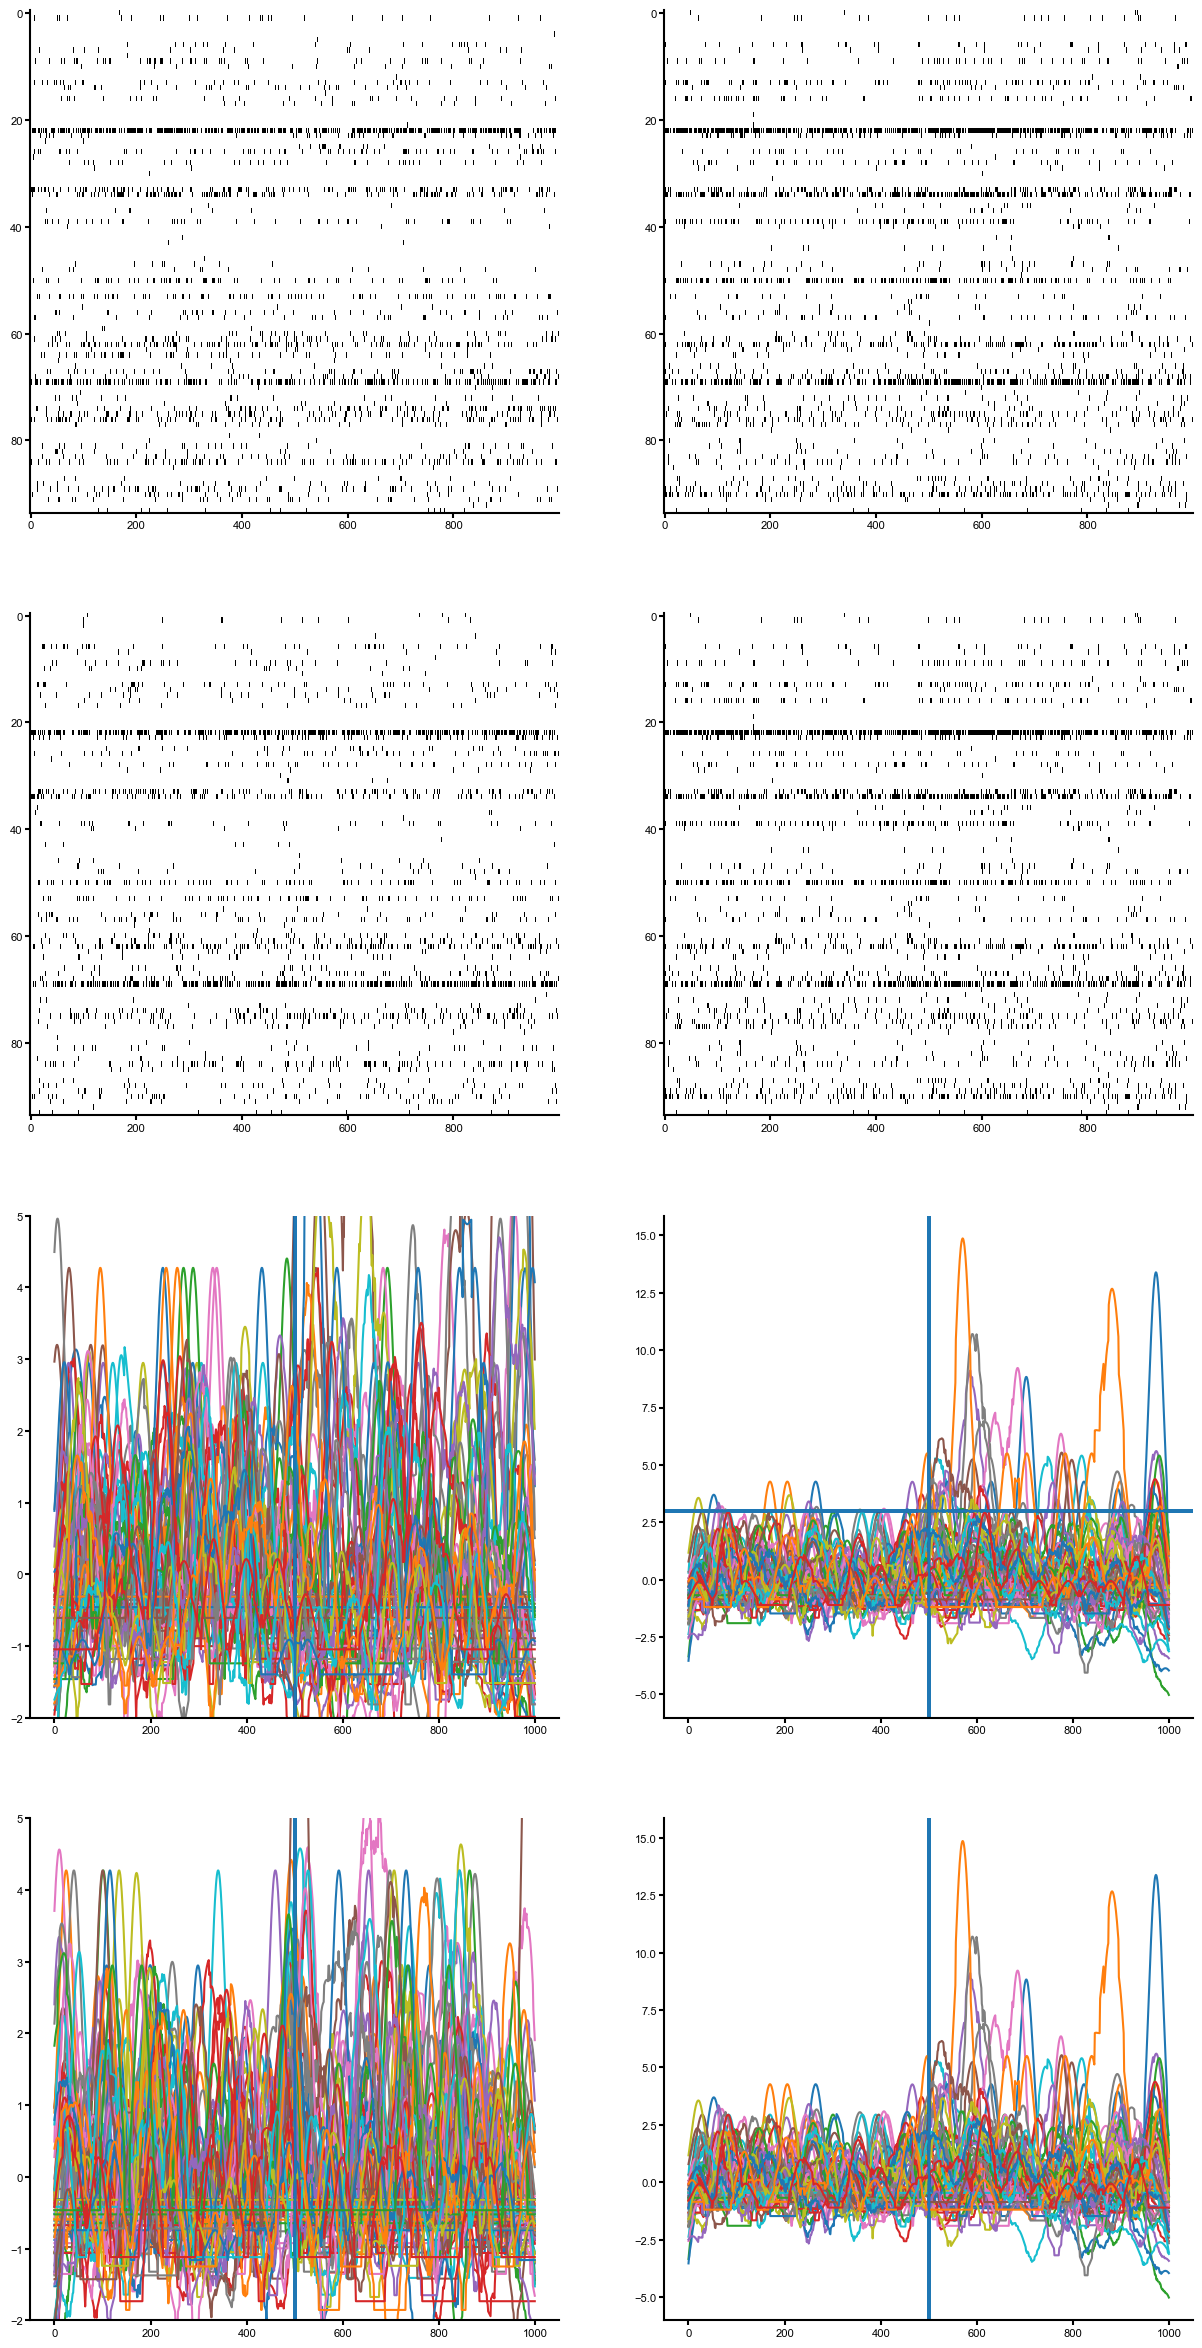

In [47]:
fig, ax = plt.subplots(4, 2, figsize=(15, 30))

block_idx = 4
model_1 = ('None', 3, 94, 'unfiltered', block_idx)
model_2 = ('additive', 3, 256, 'unfiltered', block_idx)

block_start, block_end = task.seq_periods_eval[block_idx]

# convolve with a gaussian kernel 
kernel_size = 50 
sigma = 15 
gaussian_kernel = gaussian(kernel_size, sigma) 
gaussian_kernel /= gaussian_kernel.sum() 

ax[0, 0].imshow(spike_preds[model_1].T, aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[0, 1].imshow(task.data_eval[block_start:block_end, :].T, aspect='auto', cmap='Greys', interpolation='none', vmax=1)
    
ax[1, 0].imshow(spike_preds[model_2].T, aspect='auto', cmap='Greys', interpolation="none", vmax=1)
ax[1, 1].imshow(task.data_eval[block_start:block_end, :].T, aspect='auto', cmap='Greys', interpolation='none', vmax=1)

    # ax[i, 0].set_title(f'Generated Spikes: {model}. Baseline period {i}')
    # ax[i, 1].set_title('Spikes from DTT')
for i in range(model_1[2]): 
    conv_gen_1 = convolve(spike_preds[model_1][:, i], gaussian_kernel, mode='same')
    conv_gen_2 = convolve(spike_preds[model_2][:, i], gaussian_kernel, mode='same')
    
    conv_test = convolve(task.data_eval[block_start:block_end, i], gaussian_kernel, mode='same') 
    partial_idx = len(conv_gen_1) // 2
    conv_gen_1 = (conv_gen_1 - conv_gen_1[:partial_idx].mean()) / conv_gen_1[:partial_idx].std()
    conv_gen_2 = (conv_gen_2 - conv_gen_2[:partial_idx].mean()) / conv_gen_2[:partial_idx].std()
    
    conv_test = (conv_test - conv_test[:partial_idx].mean()) / conv_test[:partial_idx].std()

    ax[2, 0].plot(conv_gen_1) 
    ax[2, 1].plot(conv_test)
    ax[2, 0].axvline(len(conv_gen_1) / 2)
    ax[2, 1].axvline(len(conv_test) / 2)
    ax[2, 1].axhline(3)
    ax[2, 0].set_ylim([-2, 5])
    ax[3, 0].set_ylim([-2, 5])
    
    ax[3, 0].plot(conv_gen_2) 
    ax[3, 1].plot(conv_test)    
    ax[3, 0].axvline(len(conv_gen_2) / 2)
    ax[3, 1].axvline(len(conv_test) / 2)

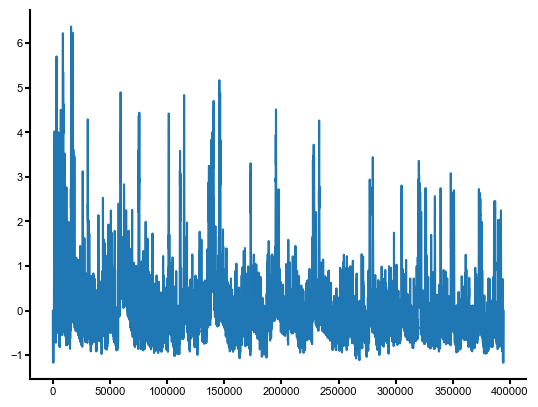

In [48]:
plt.plot(neuromod_activity)

#### 2.2. Compute evaluation metrics between generated and test spikes

In [36]:
# Parameters
tau = 4  # Decay time constant

model_vrds = {} # Van Rossum distances 
model_mres = {} # mean-rate errors 
model_isis = {} # model inter-spike interval
num_neurons = 94

for model in spike_preds.keys():
    vrds = np.zeros((num_neurons,))
    mres = np.zeros_like(vrds) 
    block_idx = model[-1] 
    block_start, block_end = task.seq_periods_eval[block_idx]
    T = block_end - block_start 
    for j in range(num_neurons):
        vrd = van_rossum_distance(spike_preds[model][:, j], task.data_eval[block_start:block_end, j], tau, T) 
        
        vrds[j] = vrd 
        # mean_rates_gen = spike_preds[model][:, j].sum() / (bin_size * T) 
        # mean_rates_test = task.data_eval[block_start:block_end, j].sum() / (bin_size * T)
        # mre = np.abs(mean_rates_gen - mean_rates_test) 
        # mres[j] = mean 
    mres = mean_rate(spike_preds[model].T.numpy(), task.data_eval[block_start:block_end, :].T.numpy())
    model_vrds[model] = (vrds.sum())
    model_mres[model] = (mres.sum()) 

    print(f'{model}: VRD: {model_vrds[model]}, MRE: {model_mres[model]}')

('None', 3, 94, 'filtered', 0): VRD: 562.8267594452635, MRE: 29.098870762711865
('None', 3, 94, 'filtered', 1): VRD: 840.5545509095808, MRE: 31.485705508474577
('None', 3, 94, 'filtered', 2): VRD: 224.0534143831737, MRE: 6.08234033203125
('None', 3, 94, 'filtered', 3): VRD: 216.49253443761805, MRE: 1.7169681396484375
('None', 3, 94, 'filtered', 4): VRD: 203.92450912390325, MRE: 2.58085107421875
('None', 3, 94, 'filtered', 5): VRD: 217.28760659632252, MRE: 2.531521240234375
('None', 3, 94, 'filtered', 6): VRD: 233.7936893347774, MRE: 2.993085205078125
('None', 3, 94, 'filtered', 7): VRD: 239.38082683632916, MRE: 3.360968017578125
('None', 3, 94, 'unfiltered', 0): VRD: 564.8605200700368, MRE: 23.879966101694915
('None', 3, 94, 'unfiltered', 1): VRD: 847.495223900216, MRE: 38.52285169491525
('None', 3, 94, 'unfiltered', 2): VRD: 218.7981670754473, MRE: 3.953936279296875
('None', 3, 94, 'unfiltered', 3): VRD: 206.1249656318684, MRE: 2.211265869140625
('None', 3, 94, 'unfiltered', 4): VRD: 

#### 2.3. Compute the log-likelihood of the test data under models

In [30]:
ll_xs = {}

ll_x_func = (
    lambda x, mu: torch.distributions.Poisson(mu)
    .log_prob(x)
    .sum()
)

for model in models.keys():
    # if model[2] != 94 and model[2] != 95: continue 
    vae = models[model]
    neuromod = model[0]
    for i, block in enumerate(task.seq_periods_eval):
        block_start = block[0]
        block_end = block[1]
        T = block_end - block_start 
        sim_s, s_test_block = False, None 
        if neuromod != 'None':
            s_test_block = task.s_test[:, block_start:block_end].unsqueeze(0)
        if neuromod == 'additive': sim_s = True 
        _, _, _, _, _, _, ll, _ = vae.forward_VGTF(task.data_eval[block_start:block_end, :].T.unsqueeze(0), 
                                                   s=s_test_block, 
                                                   sim_s=sim_s, 
                                                   sim_v=False, 
                                                   out_likelihood='Poisson',
                                                   resample='systematic', 
                                                   u=torch.zeros((1, 0, task.data_eval.shape[0])))
        print(model, i, ll)

('None', 3, 94, 'filtered') 0 tensor([-14.8882])
('None', 3, 94, 'filtered') 1 tensor([-18.4431])
('None', 3, 94, 'filtered') 2 tensor([-19.7839])
('None', 3, 94, 'filtered') 3 tensor([-17.7667])
('None', 3, 94, 'filtered') 4 tensor([-17.8873])
('None', 3, 94, 'filtered') 5 tensor([-19.5754])
('None', 3, 94, 'filtered') 6 tensor([-20.3659])
('None', 3, 94, 'filtered') 7 tensor([-21.0666])
('None', 3, 94, 'unfiltered') 0 tensor([-14.9061])
('None', 3, 94, 'unfiltered') 1 tensor([-18.4409])
('None', 3, 94, 'unfiltered') 2 tensor([-19.8041])
('None', 3, 94, 'unfiltered') 3 tensor([-17.7506])
('None', 3, 94, 'unfiltered') 4 tensor([-17.8847])
('None', 3, 94, 'unfiltered') 5 tensor([-19.6110])
('None', 3, 94, 'unfiltered') 6 tensor([-20.3532])
('None', 3, 94, 'unfiltered') 7 tensor([-21.0691])
('None', 3, 256, 'filtered') 0 tensor([-15.3122])
('None', 3, 256, 'filtered') 1 tensor([-18.8043])
('None', 3, 256, 'filtered') 2 tensor([-20.0803])
('None', 3, 256, 'filtered') 3 tensor([-17.9052])


### Compare models per trial block

In [ ]:
# evaluate on 2nd block all models with 94 neurons
eval_block = 2
for key in spike_preds.keys():
    neuromod, rank, N, block = key 
    if block == eval_block:
         

In [47]:
task.data.shape, block_start, block_end

(torch.Size([66375, 94]), 27125, 28125)

In [79]:
next(iter(dataloader))

[tensor([[[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 1., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 1.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.]],
 
         ...,
 
         [[0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          [0., 0., 0.,  ..., 0., 0., 0.],
          ...,
          [1., 0., 0.,  ..., 1., 

In [85]:
dataloader = DataLoader(
        task, batch_size=256, shuffle=True
    )
data_sample = next(iter(dataloader)) 
inputs, stim, s = data_sample
sim_s = False 
s = None 
ll, _, _, _, _, _, _, _ = models[('no_neuromodulation', 3, 512)].forward_VGTF(inputs, s=s, sim_s=sim_s, sim_v=False, resample='systematic', u=stim)

In [86]:
ll.mean().item()

-120.94171905517578

In [77]:
test = task.data[t_start:t_start + 100, :].T.unsqueeze(0)
s_block = task.s_train[:, t_start:t_start+100]
models[('additive', 3, 95)].eval()
loss, _, _, _, _, _, ll, _ = models[('additive', 3, 95)].forward_VGTF(test, s=s_block.unsqueeze(0), sim_s=True, sim_v=False, resample='systematic', u=torch.zeros((1, 0, task.data_eval.shape[0])))
ll, loss 

(tensor([-95.5780]), tensor([-95.5780], grad_fn=<MeanBackward1>))

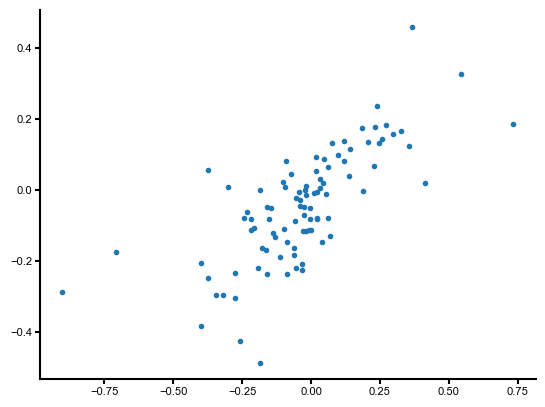

In [35]:
plt.scatter(models[('additive', 3, 94)].rnn.transition.A.detach(), models[('additive', 3, 95)].rnn.transition.A.detach())

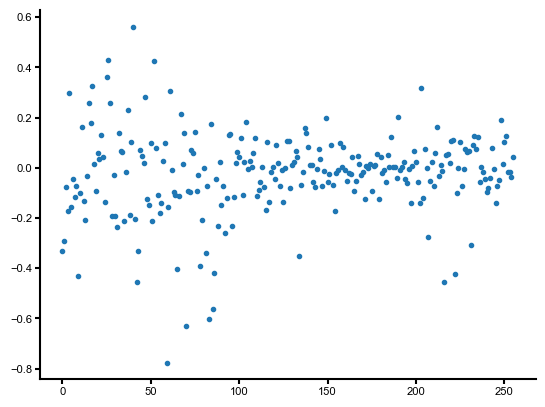

In [88]:
plt.scatter(np.arange(0, models[('additive', 3, 256)].rnn.transition.A.shape[0]), models[('additive', 3, 256)].rnn.transition.A.detach())

In [33]:
lmd.shape, data_eval.shape

(torch.Size([81, 7500]), torch.Size([7500, 81]))

In [36]:
mean_rate_errors.sum(axis=1), mean_rate_errors.mean(axis=1)

(array([156.72542383, 158.61695064]), array([1.93488178, 1.95823396]))

### Compute log likelihood of test data under models

In [80]:
test_samples.shape

(111, 33750)

In [ ]:
data_eval = torch.from_numpy(test_samples.T).to(torch.float32)[start_latent:T, :]
for neuromod in neuromodulation: 
    for rank in [1, 2, 3, 4]:
        vae = models[(neuromod, rank)]
        z_hat, _, _, _ = vae.encoder(data_eval.T.unsqueeze(0))
        lmd = vae.rnn.get_observation(z_hat, noise_scale=0)[0, :, :, 0]
        

### Plot latent activity of Rank 2 network

In [79]:
z_hat, _, _, _ = models[1].encoder(data_eval.T.unsqueeze(0))
# z0 = z_hat[:, :, :1].squeeze() 
z0 = torch.tensor([-59, 10]).to(torch.float32)
Z = models[1].rnn.get_latent_time_series(time_steps=T, cut_off=1000, z0=z0, noise_scale=1.0, sim_v=False)
# Z = Z.reshape(-1, 2)

no input


Text(0.5, 1.0, 'Latent trajectory for predictions over test set')

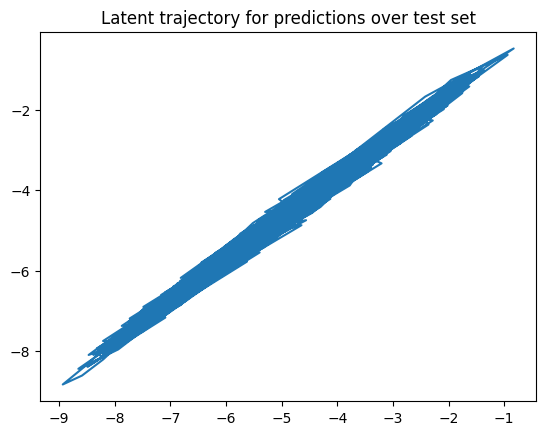

In [ ]:
plt.plot(Z[0, 0, :, 0], Z[0, 1, :, 0])
plt.title('2D Latent trajectory for predictions over test set')

Text(0.5, 1.0, 'Latent trajectory for predictions over test set')

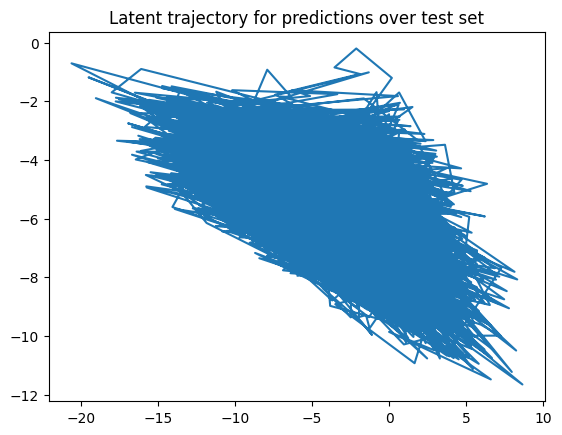

In [85]:
z_hat = z_hat.detach()
plt.plot(z_hat[0, 0, :, 0], z_hat[0, 1, :, 0])
plt.title('Latent trajectory for predictions over test set')

### Plot latent trajectory of Rank 3 model

In [87]:
z_hat, _, _, _ = models[2].encoder(data_eval.T.unsqueeze(0))
z0 = z_hat[:, :, :1].squeeze() 
# z0 = torch.tensor([-59, 10]).to(torch.float32)
Z = models[2].rnn.get_latent_time_series(time_steps=T, cut_off=1000, z0=z0, noise_scale=1.0, sim_v=False)
# Z = Z.reshape(-1, 2)

no input


Text(0.5, 0.92, '3D Latent trajectory')

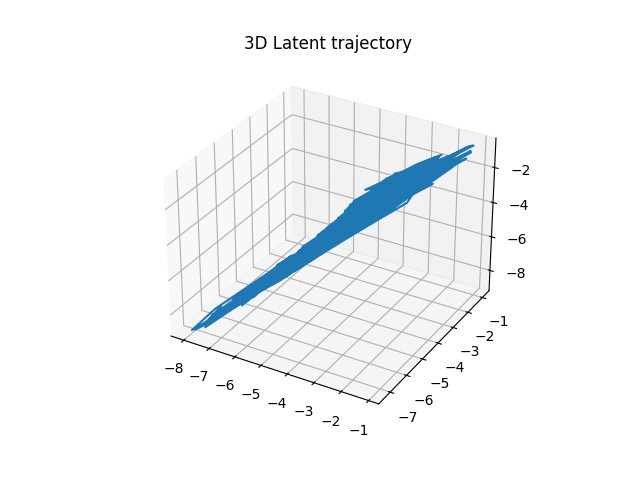

In [90]:
%matplotlib ipympl
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(Z[0, 0, :, 0], Z[0, 1, :, 0], Z[0, 2, :, 0])
ax.set_title('3D Latent trajectory')